---
title: Feature Scaling
description: A comprehensive guide to normalizing diverse variables into balanced,
  uniformly scaled data that optimizes machine learning model performance.
author: Md Muztahid Hassan
date: '2026-05-19 23:38:00'
toc: true
execute:
  warning: false
  echo: true
order: 11
---


## Introduction

Feature Scaling is a technique to standardize the independent features present in a dataset in a specific range. 

| IQ | CGPA | Placement |
|----|------|-----------|
| 110 | 3.5 | Yes |

Look at this table. The IQ and CGPA have different number ranges. If we use these features directly in a machine learning model, the model might give more weight to the feature with a larger range (IQ) and less weight to the feature with a smaller range (CGPA). This can lead to biased predictions.

To do the scaling, there are two types of feature scaling.

1. Standardization (z-score normalization)
2. Normalization (Min-Max Scaling)

## Standardization (z-score normalization)

$$z = \frac{x - \mu}{\sigma}$$

Where:

* $z$ is the calculated z-score
* $x$ is the original data value
* $\mu$ is the population mean (average) of the dataset
* $\sigma$ is the population standard deviation of the dataset

Here is an example,

| Age | Scaled Age (Z-Score) |
| --- | --- |
| 27 | -0.42 |
| 15 | -1.10 |
| 33 | -0.08 |
| 63 | 1.61 |

The mean($\mu$) of `Age` column is 34.5 and the standard deviation ($\sigma$) is 17.68. If we use these two value and calculate the `Scaled Age` column using the formula, we will get the actual standized value.

> There is a fixed rule for this standardized technique that is the mean of standardized values (in this case `Scaled Age`) will be 0 and the standardard deviation will be 1.

Here is an image that shows the concept of Standardization.

![Standardization](images/Standardization.png)

Now we will see this in practical. At first, let's import the library.

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns

Now we will load the dataset. You can download the dataset from <a href="Social_Network_Ads.csv" download>here</a>.

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


We don't need the `User ID` column. So we can omit this.

In [3]:
df = df.iloc[:,2:]
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [4]:
df.shape

(400, 3)

Now we will separate the data to training and testing.

In [5]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1), df['Purchased'], test_size=0.3, random_state=0)
x_train.shape, x_test.shape 

((280, 2), (120, 2))

In [6]:
x_train.head()

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000


In [7]:
pd.DataFrame(y_train.head())

,Purchased
92,0
223,1
234,0
232,1
377,0


In [8]:
x_test.head()

,Age,EstimatedSalary
132,30,87000
309,38,50000
341,35,75000
196,30,79000
246,35,50000


In [9]:
pd.DataFrame(y_test.head())

,Purchased
132,0
309,0
341,0
196,0
246,0


Now we will use the `Standardization` technique.

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train)

x_train_scaled = pd.DataFrame(scaler.transform(x_train), columns=x_train.columns)
x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns)

### The Golden Rule: Why don't we `fit` the test data?

You might wonder why there isn't a line of code saying `scaler.fit(x_test)`.

In machine learning, your test data represents "unseen future data." If you calculate the mean and standard deviation using the test data, you are allowing information about your test set to "leak" into your model before you actually test it. This is called **Data Leakage**, and it will give you a falsely high accuracy score that will crash when deployed in the real world.

By only fitting on `x_train`, you ensure your model is scaling the "future" data based solely on the rules it learned from the past.

The means of `Age` and `EstimatedSalary` columns.

In [11]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [12]:
x_train_scaled.head()

,Age,EstimatedSalary
0,-1.163172,-1.584970
1,2.170181,0.930987
2,0.013305,1.220177
3,0.209385,1.075582
4,0.405465,-0.486047


Here we can see that the range of the data has changed.

Let's see all the info of the `x_train` and `x_train_scaled` data. 

In [13]:
np.round(x_train.describe(), 2)

,Age,EstimatedSalary
count,280.00,280.00
mean,37.86,69807.14
std,10.22,34641.20
min,18.00,15000.00
25%,30.00,43000.00
50%,37.00,70500.00
75%,46.00,88000.00
max,60.00,150000.00


In [14]:
np.round(x_train_scaled.describe(), 2)

,Age,EstimatedSalary
count,280.00,280.00
mean,0.00,0.00
std,1.00,1.00
min,-1.95,-1.58
25%,-0.77,-0.78
50%,-0.08,0.02
75%,0.80,0.53
max,2.17,2.32


Look at the mean and standard deviation of the table for the scaled data. The mean is 0 and the standard deviation is 1. But for the non-scaled data, they are different.

### Effect of Scaling
Now we will see the visualization.

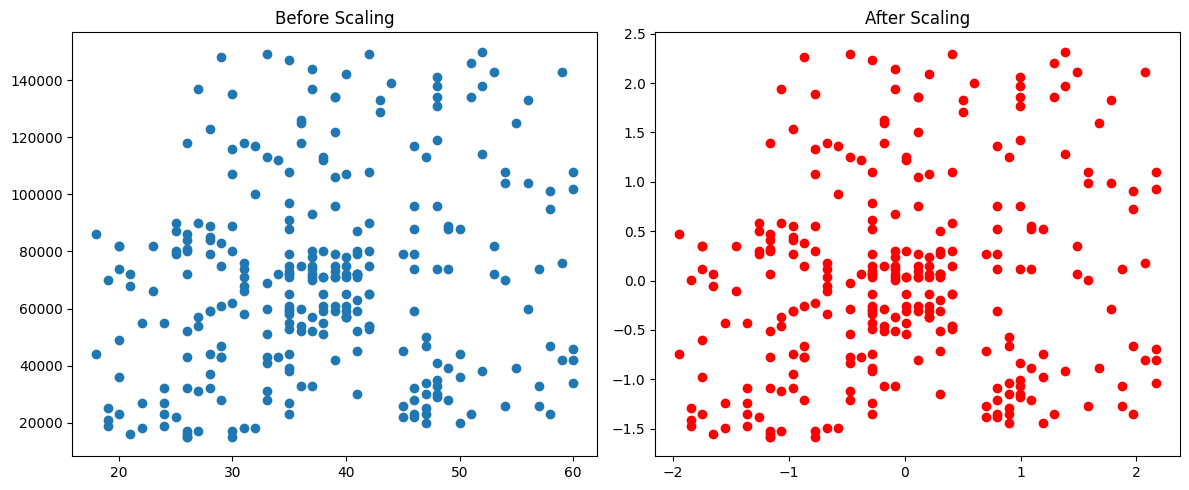

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].set_title("Before Scaling")
ax[0].scatter(x_train['Age'], x_train['EstimatedSalary'])

ax[1].set_title("After Scaling")
ax[1].scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'], color='red')

fig.tight_layout()
plt.show()

Look at the graphs carefully, the scatter plot is not changed. It only changed the spread or the range. The distance between the points is remains the same.

> **Question:** Does scaling remove the outliers in the dataset?
> The answer is no because scaling only change the spread of the dataset. It merely changes their units, meaning a massive outlier remains proportionally massive on the new scale. 

Now we will see the KDE plot of both datasets.

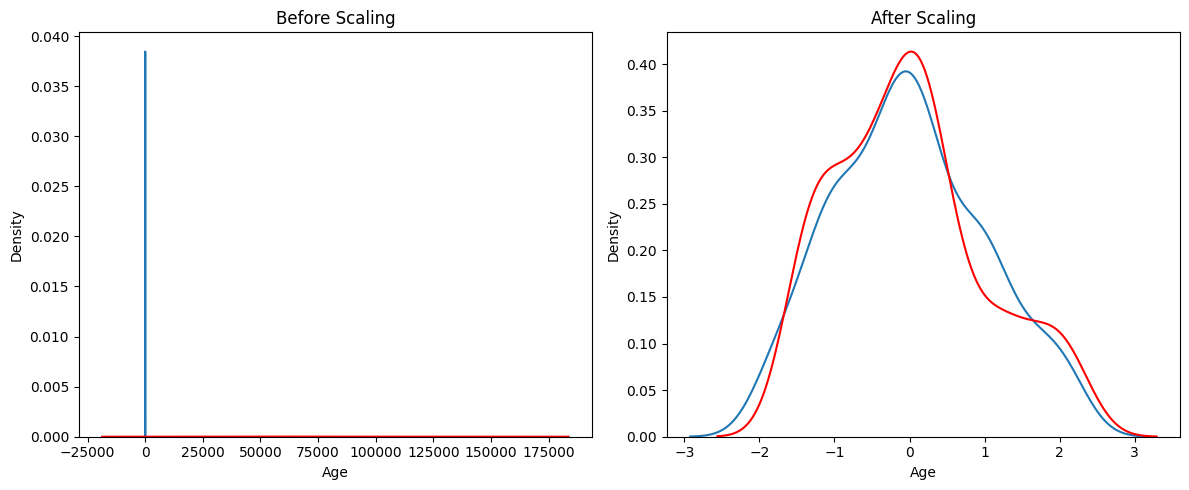

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].set_title("Before Scaling")
sns.kdeplot(data= x_train, x='Age', ax=ax[0])
sns.kdeplot(data= x_train, x='EstimatedSalary', color='red', ax=ax[0])

ax[1].set_title("After Scaling")
sns.kdeplot(data= x_train_scaled, x='Age', ax=ax[1])
sns.kdeplot(data= x_train_scaled, x='EstimatedSalary', color='red', ax=ax[1])

fig.tight_layout()
plt.show()

Look at the bell curves of the dataset before and after scaling. Though both features are normally distributed, the graph before scaling does not show that. When two columns are plotted at the same place, they will show this problem.

Now we will see that the actual data of the `Age` column and scaled data of the `Age` column are the same. Just the range is changed.

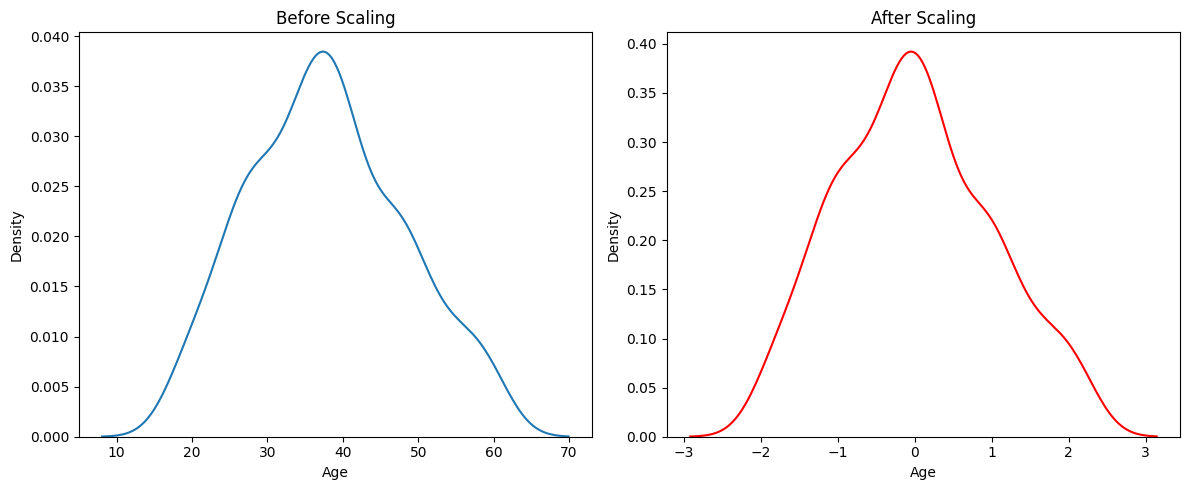

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].set_title("Before Scaling")
sns.kdeplot(data=x_train, x='Age', ax=ax[0])

ax[1].set_title("After Scaling")
sns.kdeplot(data=x_train_scaled, x='Age', color='red', ax=ax[1])

fig.tight_layout()
plt.show()

Same thing we can apply on the `EstimatedSalary` column.

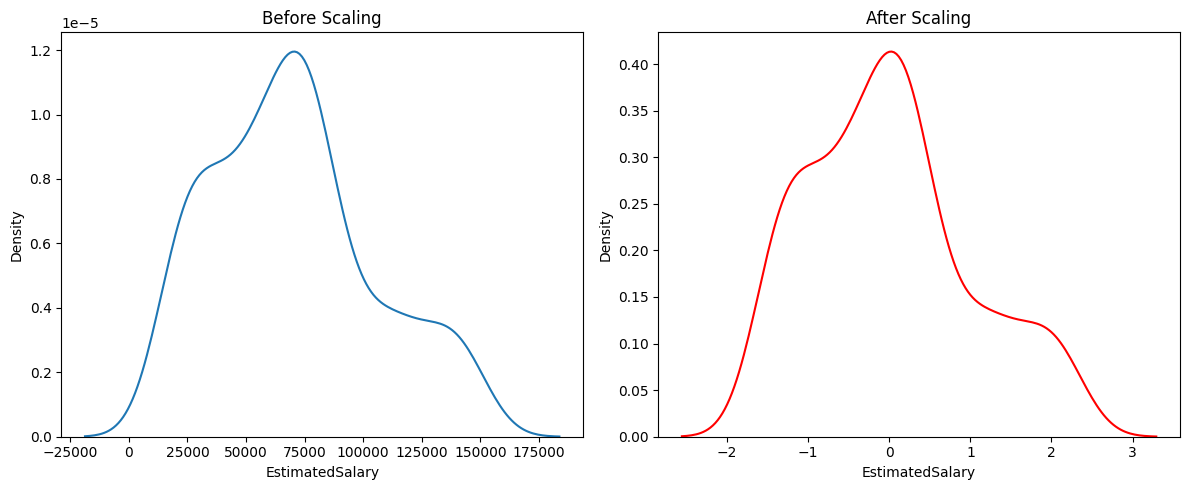

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].set_title("Before Scaling")
sns.kdeplot(data=x_train, x='EstimatedSalary', ax=ax[0])

ax[1].set_title("After Scaling")
sns.kdeplot(data=x_train_scaled, x='EstimatedSalary', color='red', ax=ax[1])

fig.tight_layout()
plt.show()

### Why scaling is so important?
K-Nearest Neighbors (KNN) is highly sensitive to Scaling. It is a **distance-based algorithm**. It calculates the Euclidean distance between data points to find the nearest neighbors. 

In our dataset:
* **Age** ranges from ~18 to 60.
* **EstimatedSalary** ranges from ~15,000 to 150,000.

When calculating distance: $\sqrt{(Age_1 - Age_2)^2 + (Salary_1 - Salary_2)^2}$

Because the Salary values are so much larger, the $(Salary_1 - Salary_2)^2$ term completely dominates the distance. The model effectively ignores the Age column. Scaling brings both to the same range, allowing the model to consider both features equally.

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn_scaled = KNeighborsClassifier(n_neighbors=5)

knn.fit(x_train, y_train)
knn_scaled.fit(x_train_scaled, y_train)

y_pred = knn.predict(x_test)
y_pred_scaled = knn_scaled.predict(x_test_scaled)

print("Actual", accuracy_score(y_test, y_pred))
print("Scaled", accuracy_score(y_test, y_pred_scaled))

Actual 0.825
Scaled 0.9166666666666666


As you can see, for distance-based algorithms like KNN, Scaling is not just a 'good practice'—it's **mandatory** for the model to work correctly.

### Models that do NOT need Scaling

On the other hand, **Tree-based algorithms** (like Decision Trees, Random Forests, XGBoost) are completely immune to the scale of the features. 

A decision tree splits data based on simple rules (e.g., "Is Age > 40?"). The mathematical magnitude of the number doesn't affect the split at all. Let's see this in action using a Decision Tree Classifier:

In [20]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=0)
dt_scaled = DecisionTreeClassifier(random_state=0)

dt.fit(x_train, y_train)
dt_scaled.fit(x_train_scaled, y_train)

y_pred_dt = dt.predict(x_test)
y_pred_dt_scaled = dt_scaled.predict(x_test_scaled)

print("Actual", accuracy_score(y_test, y_pred_dt))
print("Scaled", accuracy_score(y_test, y_pred_dt_scaled))

Actual 0.875
Scaled 0.875


### Effect of outlier
We will add some outlier to the data. Then we will see if there is any difference between the scaled and the non-scaled data.

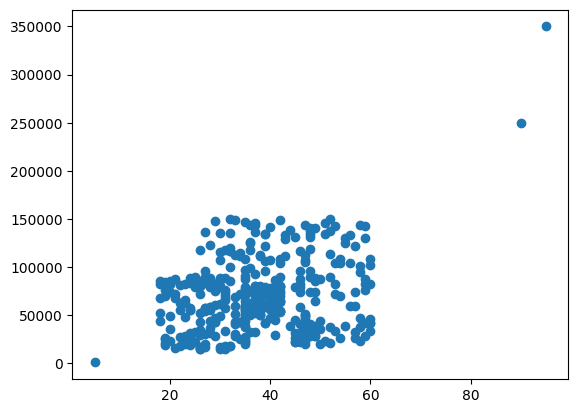

In [21]:
new_data = pd.DataFrame({
    'Age': [5, 90, 95],
    'EstimatedSalary': [1000, 250000, 350000],
    'Purchased': [0, 1, 1]
})

# Use pd.concat instead of append
df = pd.concat([df, new_data], ignore_index=True)

plt.scatter(df['Age'], df['EstimatedSalary'])

In [22]:
x_train, x_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1), df['Purchased'], test_size=0.3, random_state=0)
x_train.shape, x_test.shape 

((282, 2), (121, 2))

In [23]:
scaler = StandardScaler()
scaler.fit(x_train)

x_train_scaled = pd.DataFrame(scaler.transform(x_train), columns=x_train.columns)
x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns=x_test.columns)

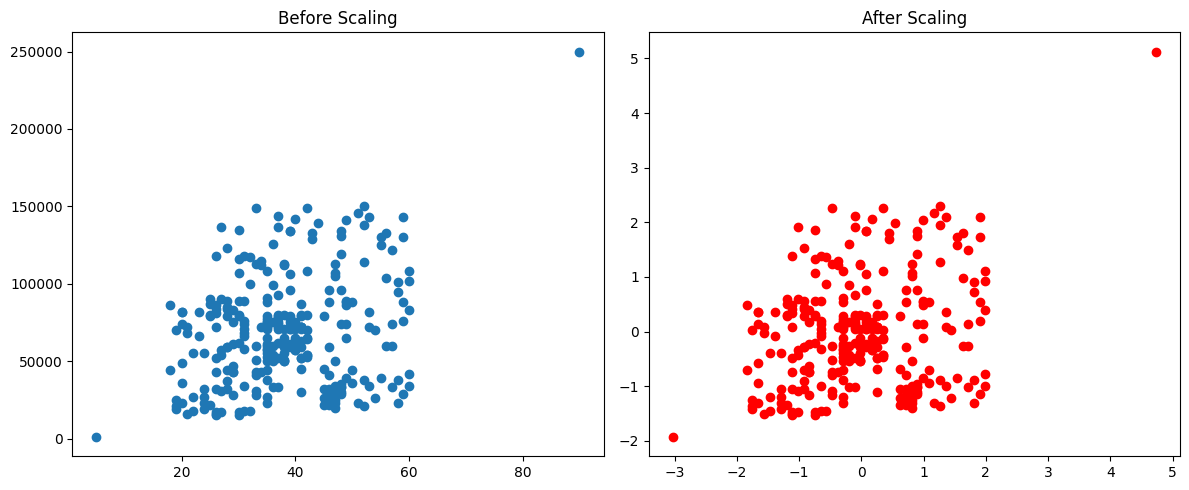

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].set_title("Before Scaling")
ax[0].scatter(x_train['Age'], x_train['EstimatedSalary'])

ax[1].set_title("After Scaling")
ax[1].scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'], color='red')

fig.tight_layout()
plt.show()

We can show that the outlier has the same effect even after scaling. So scaling does not remove the outlier problems.

## **Min-Max Scaling (Normalization)**

Min-Max Scaling is a data preprocessing technique that transforms numerical features to fall within a specific, bounded range—typically between exactly 0 and 1. By compressing or stretching the data while maintaining its original distribution shape, it prevents variables with inherently larger numbers from dominating those with smaller scales. This is especially important for distance-based machine learning algorithms like K-Nearest Neighbors (KNN) or neural networks.

### The Formula

To calculate the scaled value of a data point, you subtract the feature's minimum value and divide by its range:

$$X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

**Where:**

* $X$ is the original data point.
* $X_{min}$ is the minimum value within that feature column.
* $X_{max}$ is the maximum value within that feature column.
* $X_{scaled}$ is the newly normalized value.


| Weight | Scaled Weight (Rounded to 3 decimals) |
| --- | --- |
| 130 | 1.000 |
| 67 | 0.357 |
| 81 | 0.500 |
| 61 | 0.296 |
| 32 | 0.000 |
| 54 | 0.224 |


The minimum weight (**32**) and maximum weight (**130**) were identified, giving a range of **98** (130 - 32). Each weight was then calculated using the formula $X_{scaled} = \frac{X - 32}{98}$.

Here is an image that shows the difference between scaled and non-scaled data on scatter plot. 

![Min-Max Scaling](images/Min-Max%20Scaling.png)

Now we will see the practical. At first load the dataset. 
You can download the dataset from <a href="wine_data.csv" download>here</a>.


In [25]:
df = pd.read_csv('wine_data.csv', header=None, usecols=[0,1,2])
df.columns = ['Class label', 'Alcohol', 'Malic acid']

df.head()

,Class label,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


### Visualizing the KDE plot and Scatterplot of actual data

The distribution of the features `Alcohol` and `Malic acid`.

<Axes: xlabel='Alcohol', ylabel='Density'>

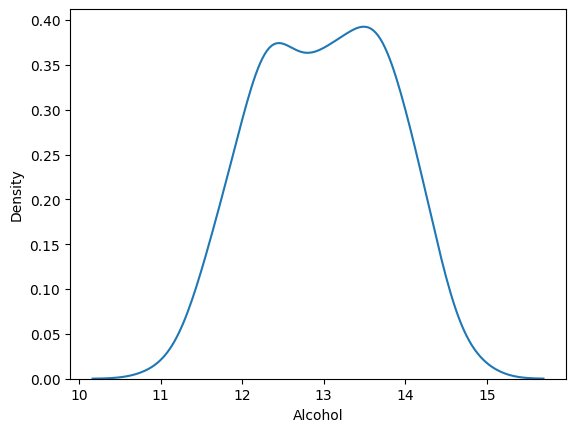

In [26]:
sns.kdeplot(data=df, x='Alcohol')

<Axes: xlabel='Malic acid', ylabel='Density'>

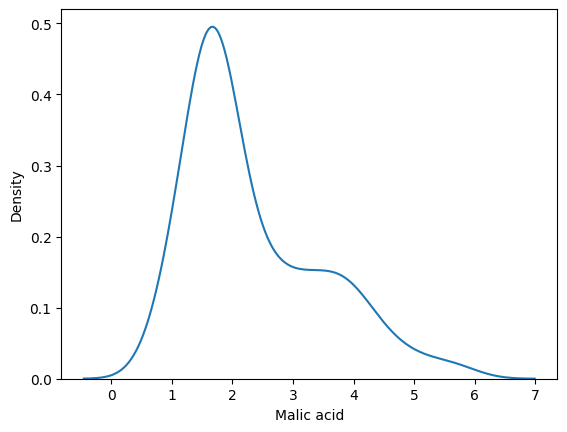

In [27]:
sns.kdeplot(data=df, x='Malic acid')

Here is a scatter-plot that shows the `Class label (The target variable)` keeping the features `Alcohol` and `Malic acid` along the x and y axis respectively.

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

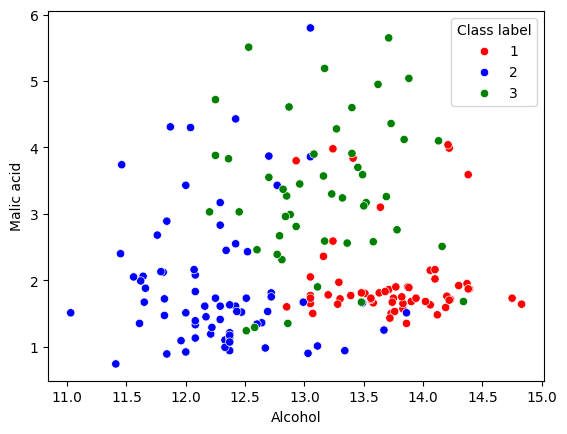

In [28]:
color_dict = {1: 'red', 2: 'blue', 3: 'green'}

sns.scatterplot(data=df, x='Alcohol', y= 'Malic acid', hue='Class label', palette=color_dict)

Now we will split the data into train and test dataset.

In [29]:
x_train, x_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1), df['Class label'], test_size=0.3, random_state=0)
x_train.shape, x_test.shape

((124, 2), (54, 2))

### Effect of scaling on Scatterplot of the dataset

Now we will find the scaled value of `x_train` and `x_test` dataset.

In [30]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(x_train)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [35]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns=x_train.columns)
x_train_scaled.head()

,Alcohol,Malic acid
0,0.720430,0.203782
1,0.319892,0.084034
2,0.602151,0.712185
3,0.572581,0.563025
4,0.760753,0.130252


In [34]:
x_test_scaled = pd.DataFrame(x_test_scaled, columns=x_train.columns)
x_test_scaled.head()

,Alcohol,Malic acid
0,0.728495,0.163866
1,0.473118,0.373950
2,0.360215,0.050420
3,0.680108,0.176471
4,0.543011,1.031513


Look at the values of the `x_train_scaled` and `x_test_scaled` dataset. The values are between 0 and 1.

In [36]:
np.round(x_train.describe(), 2)

,Alcohol,Malic acid
count,124.00,124.00
mean,12.98,2.38
std,0.80,1.14
min,11.03,0.89
25%,12.36,1.61
50%,13.04,1.88
75%,13.64,3.25
max,14.75,5.65


In [37]:
np.round(x_train_scaled.describe(), 2)

,Alcohol,Malic acid
count,124.00,124.00
mean,0.53,0.31
std,0.22,0.24
min,0.00,0.00
25%,0.36,0.15
50%,0.54,0.21
75%,0.70,0.50
max,1.00,1.00


We can see the difference between the `mean` values of before and after scaling.

Now we will see the visualization of the differences of before and after scaling. 

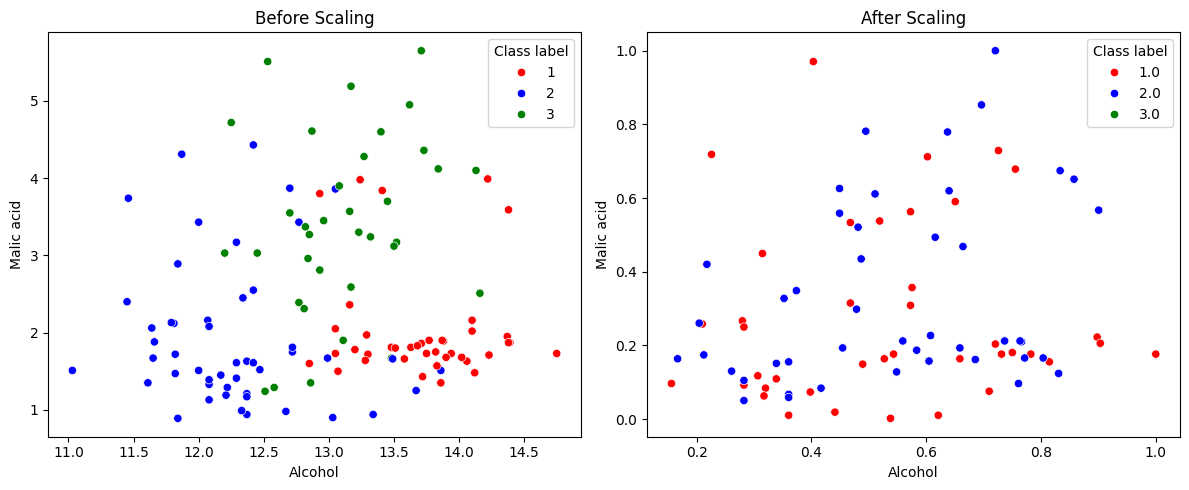

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].set_title('Before Scaling')
sns.scatterplot(data=x_train, x='Alcohol', y='Malic acid', hue=y_train, palette=color_dict, ax=ax[0])

ax[1].set_title('After Scaling')
sns.scatterplot(data=x_train_scaled, x='Alcohol', y='Malic acid', hue=y_train, palette=color_dict, ax=ax[1])

fig.tight_layout()
plt.show()

### Effect of scaling on the KDE plots of the dataset

Now we will see them on KDE plot.
At first for the `Alcohol` column.

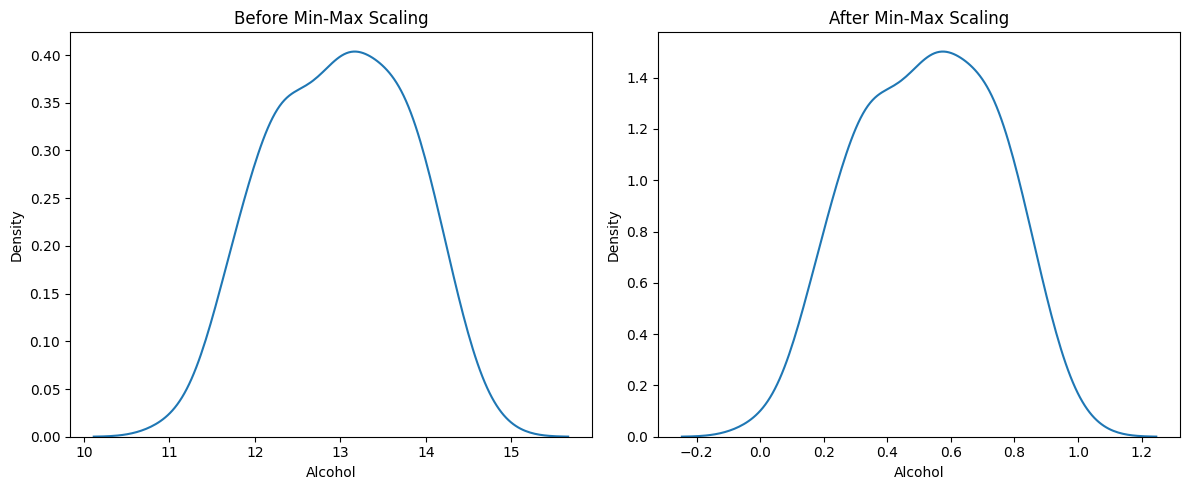

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].set_title('Before Min-Max Scaling')
sns.kdeplot(data=x_train, x='Alcohol', ax=ax[0])

ax[1].set_title('After Min-Max Scaling')
sns.kdeplot(data=x_train_scaled, x='Alcohol', ax=ax[1])

fig.tight_layout()
plt.show()

Same for the feature `Malic Acid`

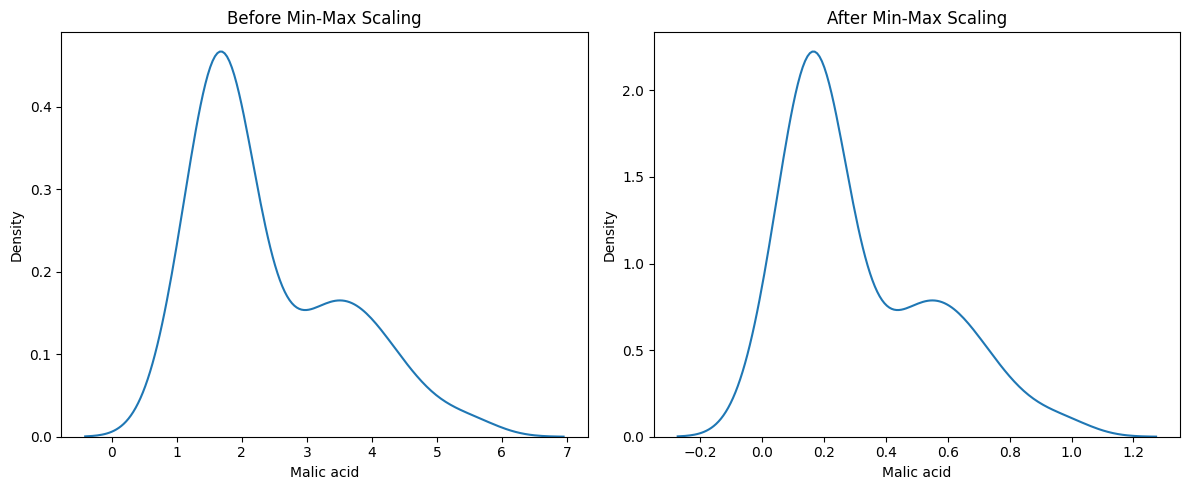

In [44]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ax[0].set_title('Before Min-Max Scaling')
sns.kdeplot(data=x_train, x='Malic acid', ax=ax[0])

ax[1].set_title('After Min-Max Scaling')
sns.kdeplot(data=x_train_scaled, x='Malic acid', ax=ax[1])

fig.tight_layout()
plt.show()